In [1]:
# Pretty inline figures + autoreload
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'


In [16]:
import os
# Better error localization if something goes wrong later
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"   # set before importing torch
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # optional, for determinism

import torch
print("torch:", torch.__version__, "cuda:", torch.version.cuda)
print("available:", torch.cuda.is_available())


torch: 2.8.0+cu128 cuda: 12.8
available: True


# Prepare to train

In [2]:
# Paths + imports you will use everywhere in this notebook
import os, sys, pathlib, numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path

# Point to your clone of the repo
REPO = Path("/nfs/team361/mv11/GGSD")           # << CHANGE if your path differs
assert REPO.exists(), f"Repo not found: {REPO}"
sys.path.append(str(REPO))

# Experiment folders for this notebook run
EXP  = Path("/nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline")
FIG  = EXP / "figs";        FIG.mkdir(parents=True, exist_ok=True)
CKPT = EXP / "checkpoints"; CKPT.mkdir(parents=True, exist_ok=True)
SMP  = EXP / "samples";     SMP.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


In [3]:
# Run once per environment (idempotent)
!pip -q install "diffusers==0.21.4" "huggingface_hub==0.19.4" >/dev/null
!pip -q install rdkit-pypi >/dev/null
print("ok")


DEPRECATION: lightning-lite 1.8.0 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of lightning-lite or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: pytorch-lightning 1.8.0 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
DEPRECATION: lightning-lite 1.8.0 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change

In [4]:
# Convert PyG PROTEINS -> list[nx.Graph] -> REPO/data/proteins.pkl

import pickle, networkx as nx
import torch.serialization as ts
from torch_geometric.data import Data, Batch
ts.add_safe_globals([Data, Batch])

os.environ.setdefault("PYG_DATASET_ROOT", "/nfs/team361/mv11/DATASETS/pyg")

from torch_geometric.datasets import TUDataset
from torch_geometric.utils import to_networkx

DATA_DIR = REPO / "data"
DATA_DIR.mkdir(exist_ok=True)
DATASET  = "proteins"
PKL      = DATA_DIR / f"{DATASET}.pkl"

if PKL.exists():
    print(f"✔ Found: {PKL} — skipping conversion")
else:
    print("Downloading/loading PyG PROTEINS...")
    ds = TUDataset(root=os.environ["PYG_DATASET_ROOT"], name="PROTEINS")

    def pyg_to_nx(d):
        G = to_networkx(d, to_undirected=True)
        # keep node features if present (not needed for proteins Stage-1)
        if d.x is not None:
            for i in range(d.num_nodes):
                G.nodes[i]["x"] = d.x[i].cpu().numpy()
        return G

    Gs = [pyg_to_nx(ds[i]) for i in range(len(ds))]

    # Clean node ids, drop isolated nodes
    Gs_clean = []
    for G in Gs:
        H = nx.convert_node_labels_to_integers(G)
        iso = [u for u,deg in H.degree() if deg == 0]
        H.remove_nodes_from(iso)
        Gs_clean.append(H)

    with open(PKL, "wb") as f:
        pickle.dump(Gs_clean, f)
    print(f"Saved {len(Gs_clean)} graphs → {PKL}")


✔ Found: /nfs/team361/mv11/GGSD/data/proteins.pkl — skipping conversion


In [5]:
from dataset.load_data_generated import LaplacianDatasetNX

dataset  = "proteins"  # proteins has NO molecular edge/node labels (unlike QM9)
k        = 16          # number of eigenpairs we’ll train on first
smallest = False       # False: largest eigenpairs (paper trains both: 16 smallest & 32 largest)
scaler   = "standard"  # matches paper

# IMPORTANT: pass ds_filename without .pkl; the class appends ".pkl"
ds_filename = str(REPO / "data" / dataset)

ds_train = LaplacianDatasetNX(dataset, ds_filename,
                              point_dim=k, smallest=smallest,
                              split='train_train', scaler=scaler,
                              nodefeatures=False, device="cpu")

sample = ds_train[0]
print("len(sample):", len(sample))
for i, t in enumerate(sample):
    try:
        print(f"[{i}] shape:", tuple(t.shape))
    except Exception:
        print(f"[{i}] type:", type(t))

# quick meanings:
# [0] φ eigenvectors (N x (k + feature_size))
# [1] λ eigenvalues  (1 x (k + feature_size))  # many datasets store as 1-row
# [2] m node mask    (N,) or (N,1)
# [3] em eig mask    (k + feature_size,)


len(sample): 4
[0] shape: (620, 16)
[1] shape: (16,)
[2] shape: (620,)
[3] shape: (16,)


## Training Diffusion (Stage 1)

In [6]:
import pytorch_lightning as pl
import numpy as np
import matplotlib.pyplot as plt

class History(pl.Callback):
    def __init__(self): self.records = []
    def on_train_epoch_end(self, trainer, pl_module):
        row = {"epoch": int(trainer.current_epoch)}
        for k, v in trainer.callback_metrics.items():
            try: row[k] = float(v)
            except: pass
        self.records.append(row)

def plot_history(hist, keys=("loss",), title=""):
    if not hist: return
    xs = [h["epoch"] for h in hist]
    plt.figure(figsize=(6,3))
    for k in keys:
        ys = [h.get(k, np.nan) for h in hist]
        plt.plot(xs, ys, marker="o", label=k)
    plt.xlabel("epoch"); plt.title(title); plt.legend(); plt.grid(alpha=.3); plt.show()


In [7]:
# Reload and patch models.diffusion.SpectralDiffusion safely
from importlib import reload
import models.diffusion as md
reload(md)
from models.diffusion import SpectralDiffusion

# --- (A) Simpler optimizer (no schedulers) ---
def _cfg_opts(self):
    import torch
    return torch.optim.Adam(self.parameters(), lr=self.args.lr)

def _train_step_no_sched(self, batch, batch_idx):
    opt = self.optimizers()
    x  = batch[0].float()
    y  = batch[1].float()
    m  = batch[2].float()
    em = batch[3].float()
    loss = self.get_loss(x, y, m=m, em=em)
    self.manual_backward(loss)
    opt.step(); opt.zero_grad()
    self.log('loss', float(loss.detach().cpu()), on_step=False, on_epoch=True)

SpectralDiffusion.configure_optimizers = _cfg_opts
SpectralDiffusion.training_step        = _train_step_no_sched
SpectralDiffusion.on_train_epoch_end   = lambda self: None  # we stepped optim already

# --- (B) Safer validation hook (both PL list/single val loader) ---
def _safe_val_end(self):
    # Option: keep it light to avoid long eval during early experiments
    LIGHT_VALIDATION = True
    if self.trainer.train_dataloader is None:
        return

    if LIGHT_VALIDATION:
        # Just log a tiny proxy: sample noise once and report average magnitude
        try:
            bs = 4
            k  = self.hparams.k + getattr(self.hparams, "feature_size", 0)
            N  = min(32, getattr(self.hparams, "n_max", 64))
            xy = torch.randn(bs, N+1, k, device=self.diffusion.init_layer_PHI[0].weight.device)
            m  = torch.ones(bs, N, device=xy.device)
            em = torch.ones(bs, k, device=xy.device)
            # One forward pass of the transformer to ensure it behaves
            _ = self.diffusion(xy, torch.zeros(bs, device=xy.device), m)
            self.log('val_proxy', float(xy.abs().mean().item()), on_step=False, on_epoch=True)
        except Exception as e:
            # don't crash validation; log nothing on failure
            pass
        return

    # Heavy path (paper-like) — only if you turn LIGHT_VALIDATION=False above
    # Fix val loader access across PL versions:
    vld = self.trainer.val_dataloaders
    test_set = (vld[0].dataset if isinstance(vld, (list, tuple)) else vld.dataset)
    train_set = self.trainer.train_dataloader.dataset

    degree, cluster, orbit, unique, novel, spectral = self.evaluate(
        train_set, test_set, device=self.diffusion.init_layer_PHI[0].bias.device
    )
    # Log metrics
    for name, val in [
        ('degree', degree), ('cluster', cluster), ('orbit', orbit),
        ('unique', unique), ('novel', novel), ('spectral', spectral),
    ]:
        self.log(name, torch.tensor(val).float(), on_step=False, on_epoch=True)

SpectralDiffusion.on_validation_epoch_end = _safe_val_end
print("Patched SpectralDiffusion for notebook training.")


Patched SpectralDiffusion for notebook training.


In [8]:
import argparse, pytorch_lightning as pl
from torch.utils.data import DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

def train_diffusion(
    dataset="proteins", k=16, smallest=False, scaler="standard",
    batch_size=128, lr=1e-4, num_steps=1000, layers=6, latent_dim=256,
    seed=2023, max_epochs=3000, val_check_interval=2000, patience=50
):
    pl.seed_everything(seed)

    # Datasets
    ds_filename = str(REPO / "data" / dataset)  # ".../data/proteins"
    nodefeatures = False  # only QM9 uses this
    train_set = LaplacianDatasetNX(dataset, ds_filename, point_dim=k, smallest=smallest,
                                   split='train_train', scaler=scaler,
                                   nodefeatures=nodefeatures, device="cpu")
    valid_set = LaplacianDatasetNX(dataset, ds_filename, point_dim=k, smallest=smallest,
                                   split='train_val', scaler=scaler,
                                   nodefeatures=nodefeatures)
    train_set.get_extra_data(False)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
    valid_loader = DataLoader(valid_set, batch_size=len(valid_set), shuffle=False, num_workers=0)

    # Model hparams (feature_size = extra channels beyond k)
    feature_size = train_set[0][0].shape[-1] - k
    args = argparse.Namespace(
        # diffusion core
        num_steps=num_steps, residual=True,
        # data
        dataset=dataset, k=k, smallest=smallest, scaler=scaler, feature_size=feature_size,
        # score model
        latent_dim=latent_dim, layers=layers, use_mask=True,
        # optim/schedule
        batch_size=batch_size, lr=lr, max_epochs=max_epochs,
        device=device, val_check_interval=val_check_interval, log_every_n_steps=200,
        # misc
        wandb=False, model_tag="nb",
    )
    model = SpectralDiffusion(args)

    # Callbacks
    ckpt_cb = ModelCheckpoint(
        dirpath=str(CKPT), filename=f"diffusion_{dataset}_k{k}"+"-{epoch:04d}",
        save_last=True, save_top_k=1, monitor="loss", mode="min"
    )
    es_cb   = EarlyStopping(monitor="loss", min_delta=1e-4, patience=patience, mode="min")
    hist    = History()

    trainer = pl.Trainer(
        accelerator="auto",
        callbacks=[hist, ckpt_cb, es_cb],
        logger=False,
        log_every_n_steps=200,
        check_val_every_n_epoch=None,
        val_check_interval=val_check_interval,
        max_epochs=max_epochs,
        num_sanity_val_steps=0,
    )
    trainer.fit(model, train_loader, valid_loader)

    # Force-save a deterministic final ckpt path
    final_ckpt = CKPT / f"diffusion_{dataset}_k{k}-final.ckpt"
    trainer.save_checkpoint(str(final_ckpt))

    best = ckpt_cb.best_model_path or ckpt_cb.last_model_path or str(final_ckpt)
    print("Best diffusion checkpoint:", best)
    return best, hist.records


Global seed set to 2023
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:606: UserWarning: Checkpoint directory /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type        | Params
------------------------------------------
0 | diffusion | Transformer | 20.1 M
------------------------------------------
20.1 M    Trainable params
0         Non-trainable params
20.1 M    Total params
80.464    Total estimated model params size (MB)
/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader

Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


Best diffusion checkpoint: /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints/diffusion_proteins_k16-final.ckpt


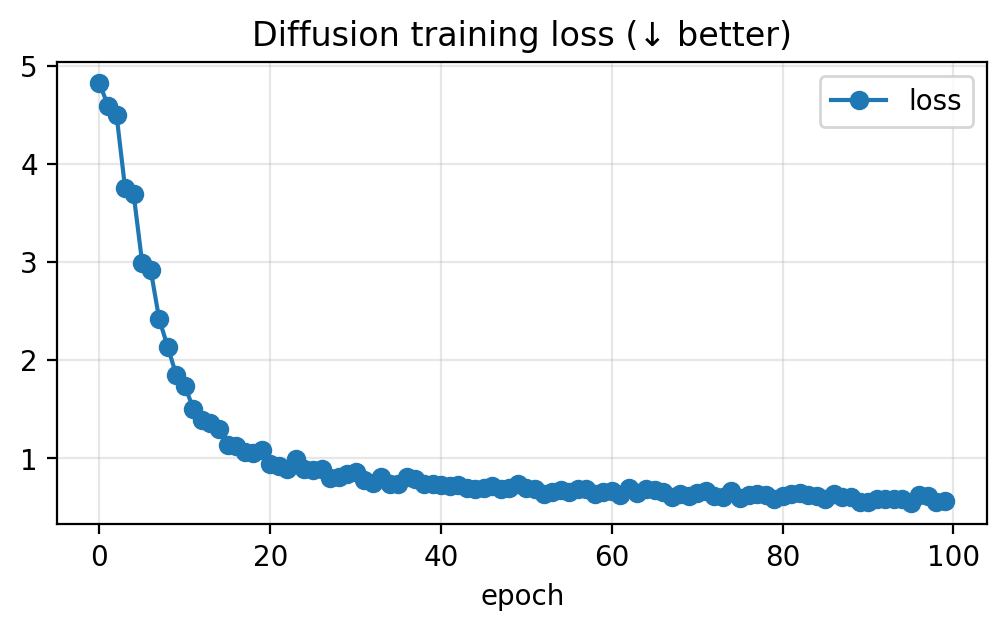

Checkpoint saved to: /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints/diffusion_proteins_k16-final.ckpt


In [29]:
diff_ckpt, diff_hist = train_diffusion(
    dataset="proteins",
    k=16,
    smallest=False,     # (paper trains both 16 smallest and 32 largest; we start here)
    scaler="standard",
    batch_size=128,
    lr=1e-4,
    num_steps=1000,
    layers=6,           # grid {6, 9, 12} in paper;
    latent_dim=256,
    seed=2023,
    max_epochs=100,    # early stopping will stop earlier if converged
    val_check_interval=2000,
    patience=100,
)

plot_history(diff_hist, ["loss"], "Diffusion training loss (↓ better)")
print("Checkpoint saved to:", diff_ckpt)


In [30]:
import glob

def resolve_diffusion_ckpt(diff_ckpt="", dataset="proteins", k=16):
    # If a working file path was passed, use it
    if isinstance(diff_ckpt, str) and diff_ckpt and os.path.isfile(diff_ckpt):
        return diff_ckpt
    # Otherwise search a few likely roots
    roots = [str(CKPT), str(REPO/"checkpoints"), ".", str(CKPT.parent)]
    seen = set()
    patterns = [f"diffusion_{dataset}_k{k}-*.ckpt", "*.ckpt"]
    for r in roots:
        if not os.path.isdir(r) or r in seen: 
            continue
        seen.add(r)
        for pat in patterns:
            hits = sorted(glob.glob(os.path.join(r, pat)), key=os.path.getmtime, reverse=True)
            if hits:
                return hits[0]
    raise FileNotFoundError("No diffusion .ckpt found. Re-run training or pass an explicit path.")

diff_ckpt = resolve_diffusion_ckpt(diff_ckpt, dataset="proteins", k=16)
print("Using diffusion checkpoint:", diff_ckpt)


Using diffusion checkpoint: /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints/diffusion_proteins_k16-final.ckpt


In [31]:
from models.diffusion import SpectralDiffusion

def sample_eigs_from_ckpt(ckpt_path, dataset="proteins", k=16, smallest=False, n_graphs=16, sampling_steps=200, seed=0):
    torch.manual_seed(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load model
    model = SpectralDiffusion.load_from_checkpoint(ckpt_path, strict=False, map_location=device)
    model.eval().to(device)
    args = model.hparams

    # A train split is only needed to get (i) n_nodes distribution and (ii) scalers
    ds_filename = str(REPO / "data" / dataset)
    train_set = LaplacianDatasetNX(dataset, ds_filename, point_dim=k, smallest=smallest,
                                   split='train_train', scaler=args.scaler, nodefeatures=False)

    # Sample a realistic set of sizes (plus n_max as sentinel)
    n_nodes = list(train_set.sample_n_nodes(max(1, n_graphs-1))) + [train_set.n_max]

    with torch.no_grad():
        XX, YY = model.sample_eigs(
            n_nodes,
            k + getattr(args, "feature_size", 0),
            scale_xy=train_set.scale_xy,
            unscale_xy=train_set.unscale_xy,
            device=device,
            num_graphs=len(n_nodes),
            reproject=False,
            sampling_steps=sampling_steps,  # paper used 200
        )
    return XX.cpu(), YY.cpu(), n_nodes

XX, YY, sizes = sample_eigs_from_ckpt(diff_ckpt, dataset="proteins", k=16, smallest=False, n_graphs=8, sampling_steps=200)
print("Eigenvectors shape:", tuple(XX.shape), "Eigenvalues shape:", tuple(YY.shape))


Eigenvectors shape: (8, 620, 16) Eigenvalues shape: (8, 1, 16)


In [34]:
import torch, numpy as np
import matplotlib.pyplot as plt

def effective_n(phi, tol=1e-12):
    """Infer the true number of nodes from padded eigenvectors."""
    return int((phi.abs().sum(dim=1) > tol).sum().item())

def orthogonality_error(phi, em=None):
    """
    || Φ^T Φ - I ||_F / k  on the active eigen-dims.
    phi: (n, k_tot)    em: (k_tot,) mask for active spectral dims (optional)
    """
    if em is None:
        k = phi.shape[1]
        Phi = phi[:, :k]
    else:
        idx = (em > 0.5).nonzero(as_tuple=False).view(-1)
        Phi = phi[:, idx]
        k = Phi.shape[1]
    G = Phi.T @ Phi
    return torch.norm(G - torch.eye(k, device=Phi.device), p='fro').item() / max(1, k)

def reconstruct_adj_via_degree(phi, lam):
    """
    Paper-style reconstruction for UNNORMALIZED Laplacian:
      - L = Φ diag(λ) Φ^T
      - degree d_i ≈ round(L_ii) clipped to >=0
      - connect node i to the |d_i| most negative off-diagonals (largest weights in -L)
    Returns a symmetric 0/1 adjacency (n x n).
    """
    with torch.no_grad():
        n, k = phi.shape
        L = (phi * lam[None, :]) @ phi.t()   # (n,n)
        diag = L.diag().cpu().numpy()
        deg = np.clip(np.rint(diag), 0, n-1).astype(int)  # integer degrees

        A = np.zeros((n, n), dtype=np.float32)
        for i in range(n):
            row = L[i].cpu().numpy().copy()
            row[i] = 0.0  # ignore self
            # most negative entries are strongest edges (since L_ij <= 0)
            nbrs = np.argsort(row)[:deg[i]]  # smallest values
            A[i, nbrs] = 1.0

        # symmetrize (keep an undirected simple graph)
        A = np.maximum(A, A.T)
        np.fill_diagonal(A, 0.0)
        return torch.from_numpy(A)


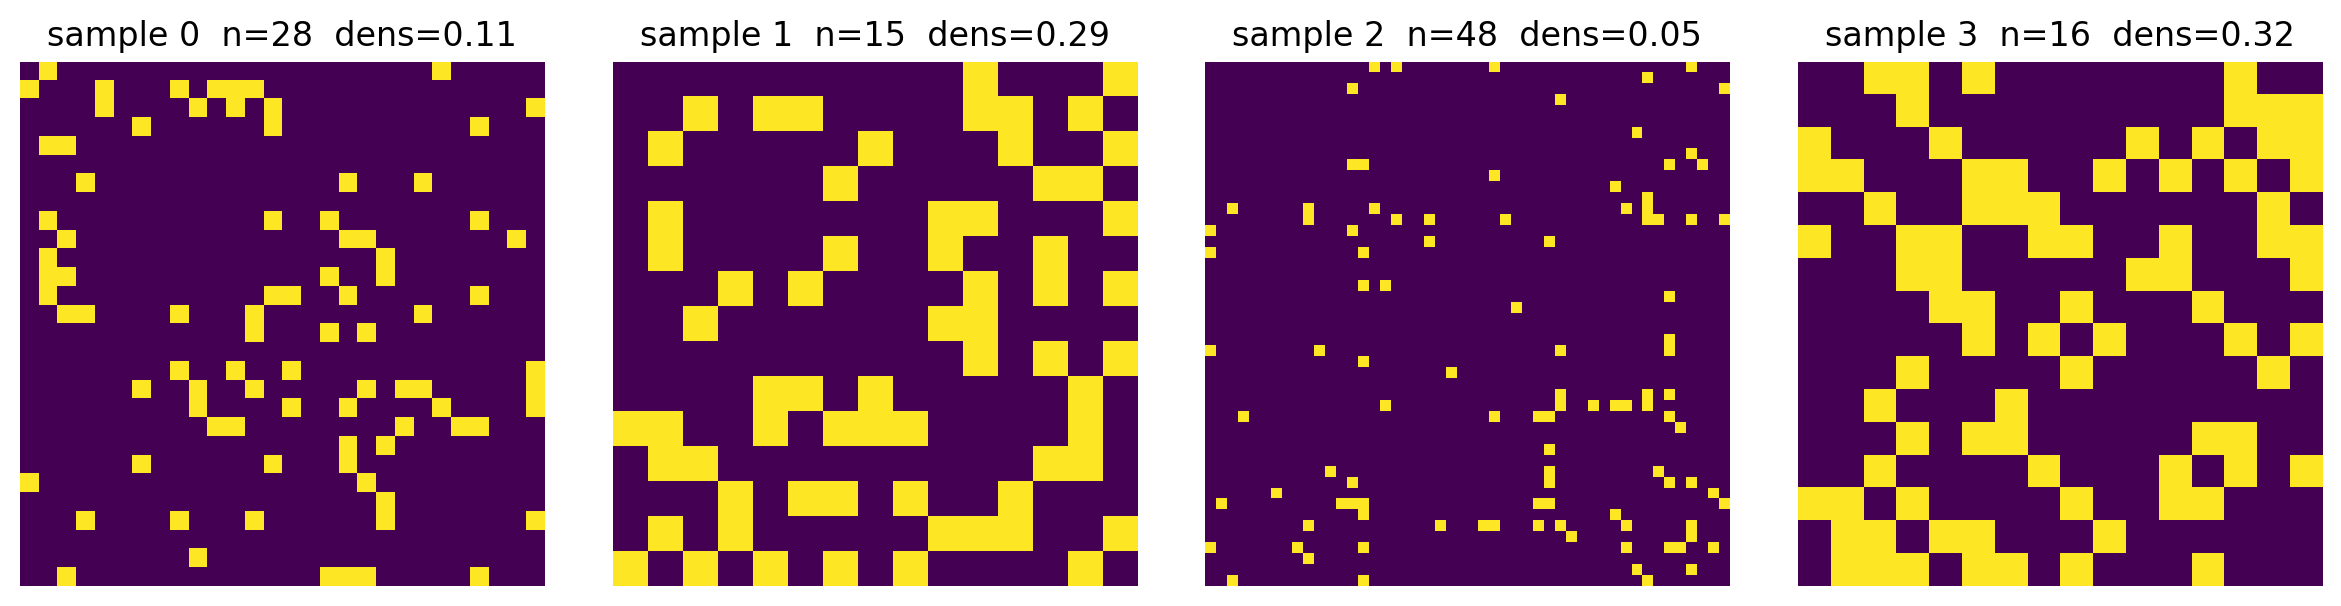

In [35]:
# Visualize first few reconstructions
n_show = min(4, XX.shape[0])
plt.figure(figsize=(3*n_show, 3))

densities = []
for i in range(n_show):
    # crop to the effective size
    n_i = effective_n(XX[i, :, :k])
    phi = XX[i, :n_i, :k]
    lam = YY[i, 0, :k]

    # degree-based reconstruction (closest to the paper's Section 5.2)
    A_deg = reconstruct_adj_via_degree(phi, lam)

    dens = float(A_deg.mean().item())
    densities.append(dens)

    ax = plt.subplot(1, n_show, i+1)
    ax.imshow(A_deg, interpolation='nearest')
    ax.set_title(f"sample {i}  n={n_i}  dens={dens:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()


orthogonality error per sample (||ΦᵀΦ - I||_F / k):
['0.156', '0.181', '0.139', '0.187', '0.219', '0.213', '0.135', '0.158']
median=0.169  90th%=0.215
degree integrality (mean |diag(L)-round(diag(L))|) per sample:
['0.20', '0.23', '0.21', '0.19', '0.25', '0.26', '0.24', '0.08']
median=0.22


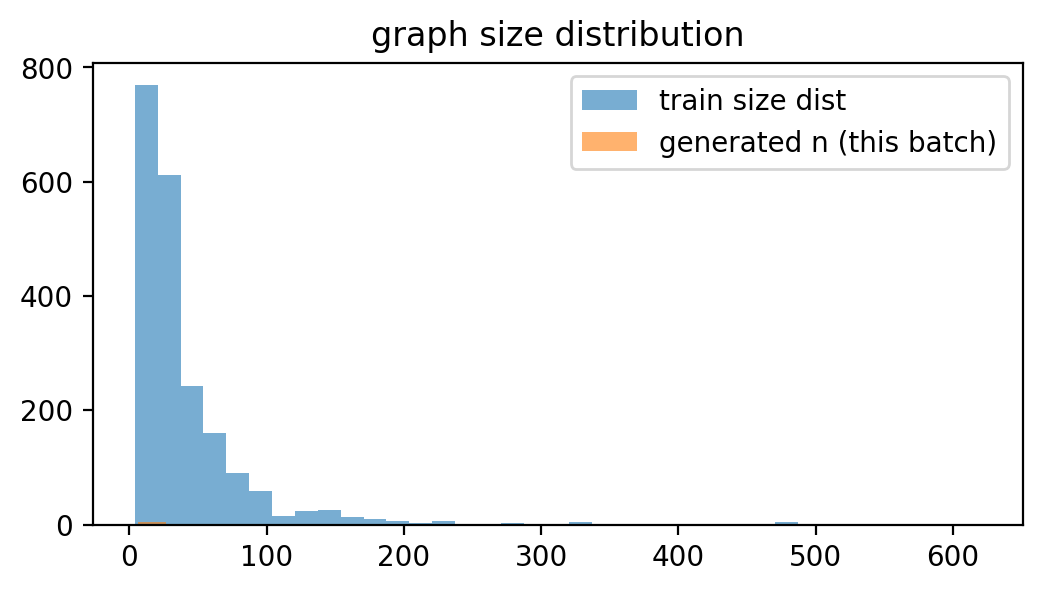

In [36]:
# 1) Orthogonality check (Φ should be ~orthonormal on active dims)
errs = []
ns   = []
for i in range(XX.shape[0]):
    n_i = effective_n(XX[i, :, :k])
    phi = XX[i, :n_i, :k]
    err = orthogonality_error(phi)
    errs.append(err); ns.append(n_i)

print(f"orthogonality error per sample (||ΦᵀΦ - I||_F / k):")
print([f"{e:.3f}" for e in errs])
print(f"median={np.median(errs):.3f}  90th%={np.percentile(errs,90):.3f}")

# 2) Degree integrality: how integer-like are diagonal entries of L?
def degree_integrality(phi, lam):
    L = (phi * lam[None, :]) @ phi.t()
    d  = L.diag().cpu().numpy()
    return float(np.mean(np.abs(d - np.rint(d))))

ints = []
for i in range(XX.shape[0]):
    n_i = effective_n(XX[i, :, :k])
    phi = XX[i, :n_i, :k]
    lam = YY[i, 0, :k]
    ints.append(degree_integrality(phi, lam))
print("degree integrality (mean |diag(L)-round(diag(L))|) per sample:")
print([f"{v:.2f}" for v in ints])
print(f"median={np.median(ints):.2f}")

# 3) Size distribution sanity: generated vs. training
from dataset.load_data_generated import LaplacianDatasetNX
train_set = LaplacianDatasetNX("proteins", str(REPO/"data"/"proteins"),
                               point_dim=k, smallest=False, split='train_train',
                               scaler="standard", nodefeatures=False)
# sample a bunch of sizes from the train distribution for comparison
train_sizes = [int(s) for s in train_set.sample_n_nodes(2048)]
plt.figure(figsize=(6,3))
plt.hist(train_sizes, bins=30, alpha=0.6, label="train size dist")
plt.hist(ns,          bins=30, alpha=0.6, label="generated n (this batch)")
plt.legend(); plt.title("graph size distribution"); plt.show()


## Train PPGN (predictor) conditioned on spectral samples

In [9]:
# (1) Config for Stage-2 — defaults assume "full" run (~10k epochs)
import argparse, os, sys, glob, numpy as np, torch
import pytorch_lightning as pl
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset

REPO = Path("/nfs/team361/mv11/GGSD")                             # your repo
EXP  = Path("/nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline")
CKPT = EXP / "checkpoints"; CKPT.mkdir(parents=True, exist_ok=True)

sys.path.append(str(REPO))

from dataset.load_data_generated import LaplacianDatasetNX
from models.diffusion import SpectralDiffusion
from models.predictor import Predictor

device = "cuda" if torch.cuda.is_available() else "cpu"

CFG = dict(
    dataset="proteins",
    k=16,
    smallest=False,
    scaler="standard",
    # generator / discriminator (paper defaults)
    generator_layers=8,
    generator_data_channels=32,
    generator_init_emb_channels=64,
    generator_noise_latent_dim=2,
    discriminator_layers=4,
    discriminator_data_channels=32,
    rec_weight=1e-1,
    normalized=True,
    disc_ori=False,
    # how many diffusion samples to mix in (train/test pools)
    n_graphs_train=512,      # bump when you scale up
    n_graphs_val=256,
    sampling_steps=200,      # paper uses 200
    # optimization
    batch_size=8,
    lr=1e-4,
    seed=2020,
    max_epochs=100,      # 10_000
    val_check_interval=1000, # validate every N steps
    wandb=False,             # flip on if you want W&B logs
)

print("Stage-2 CFG:", CFG)


Stage-2 CFG: {'dataset': 'proteins', 'k': 16, 'smallest': False, 'scaler': 'standard', 'generator_layers': 8, 'generator_data_channels': 32, 'generator_init_emb_channels': 64, 'generator_noise_latent_dim': 2, 'discriminator_layers': 4, 'discriminator_data_channels': 32, 'rec_weight': 0.1, 'normalized': True, 'disc_ori': False, 'n_graphs_train': 512, 'n_graphs_val': 256, 'sampling_steps': 200, 'batch_size': 8, 'lr': 0.0001, 'seed': 2020, 'max_epochs': 100, 'val_check_interval': 1000, 'wandb': False}


In [10]:
# (2) Helper: find/resolve the diffusion checkpoint you trained in Stage-1
import os, glob

def resolve_diffusion_ckpt(diff_ckpt="", dataset="proteins", k=16):
    if isinstance(diff_ckpt, str) and diff_ckpt and os.path.isfile(diff_ckpt):
        return diff_ckpt
    roots = [
        str(CKPT),
        str(REPO / "checkpoints"),
        str(EXP / "checkpoints"),
        ".",
    ]
    pats = [f"diffusion_{dataset}_k{k}-*.ckpt", "*.ckpt"]
    for r in roots:
        if not os.path.isdir(r): 
            continue
        for pat in pats:
            hits = sorted(glob.glob(os.path.join(r, pat)), key=os.path.getmtime, reverse=True)
            if hits:
                return hits[0]
    raise FileNotFoundError("No diffusion .ckpt found. Pass an explicit path or re-run Stage-1.")

diff_ckpt = resolve_diffusion_ckpt(dataset=CFG["dataset"], k=CFG["k"])
print("Using diffusion checkpoint:", diff_ckpt)


Using diffusion checkpoint: /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints/diffusion_proteins_k16-final.ckpt


In [6]:
def safe_cuda_report():
    import torch, traceback
    rep = {}
    try: rep["available"] = torch.cuda.is_available()
    except Exception as e: rep["available"] = f"ERR: {e}"
    try: rep["device_count"] = torch.cuda.device_count()
    except Exception as e: rep["device_count"] = f"ERR: {e}"
    try:
        if torch.cuda.is_available():
            rep["name"] = torch.cuda.get_device_name(0)
            rep["capability"] = torch.cuda.get_device_capability(0)
    except Exception as e:
        rep["name"] = rep["capability"] = f"ERR: {e}"
    try:
        # even this can crash if context is bad
        rep["mem_allocated"] = torch.cuda.memory_allocated()
        rep["mem_reserved"]  = torch.cuda.memory_reserved()
    except Exception as e:
        rep["mem_allocated"] = rep["mem_reserved"] = f"ERR: {e}"
    return rep

print(safe_cuda_report())


{'available': True, 'device_count': 1, 'name': 'NVIDIA A100-SXM4-80GB', 'capability': (8, 0), 'mem_allocated': 83778670080, 'mem_reserved': 83930120192}


In [1]:
from pathlib import Path
import torch, sys

REPO = Path("/nfs/team361/mv11/GGSD")
sys.path.append(str(REPO))

diff_ckpt = "/nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints/diffusion_proteins_k16-final.ckpt"
ds_dir   = REPO/"data"/"proteins"   # directory that contains proteins.pkl and proteins_16_smFalse_scstandard_nfFalse.torch
pairs_out = REPO/"data"/"gen_pairs_proteins_k16.pt"  # wherever you like

from models.diffusion import SpectralDiffusion
from dataset.load_data_generated import LaplacianDatasetNX

device = "cuda"
model = SpectralDiffusion.load_from_checkpoint(diff_ckpt, strict=False, map_location="cpu").eval().to(device)

train_set = LaplacianDatasetNX("proteins", ds_dir, point_dim=16, smallest=False, split="train_train", scaler="standard", nodefeatures=False)

def sample_pairs(n, steps=200):
    sizes = list(train_set.sample_n_nodes(max(1, n-1))) + [train_set.n_max]
    with torch.no_grad():
        X, Y = model.sample_eigs(
            max_nodes=sizes,
            num_eigs=16 + getattr(model.hparams, "feature_size", 0),
            scale_xy=train_set.scale_xy,
            unscale_xy=train_set.unscale_xy,
            num_graphs=len(sizes),
            oversample_mult=1,
            device=device,
            sampling_steps=steps,
            reproject=True,
        )
    return X.cpu(), Y.cpu()

gx_tr, gy_tr = sample_pairs(512, steps=200)
gx_va, gy_va = sample_pairs(256, steps=200)
torch.save({"gen_x_train": gx_tr, "gen_y_train": gy_tr, "gen_x_val": gx_va, "gen_y_val": gy_va}, pairs_out)
print("Saved", pairs_out)


Saved /nfs/team361/mv11/GGSD/data/gen_pairs_proteins_k16.pt


In [6]:
# Free Stage-1 model & cache
try:
    del model  # the SpectralDiffusion used for sampling
except NameError:
    pass
import gc, torch
gc.collect()
torch.cuda.empty_cache()
print(safe_cuda_report())  # should now show small mem_reserved


{'available': True, 'device_count': 1, 'name': 'NVIDIA A100-SXM4-80GB', 'capability': (8, 0), 'mem_allocated': 37597184, 'mem_reserved': 144703488}


In [7]:
# Pretty inline figures + TF32 speed on A100
%config InlineBackend.figure_format = 'retina'

import os, sys
from pathlib import Path
import torch

torch.set_float32_matmul_precision('medium')   # A100-friendly
os.environ.setdefault("CUDA_LAUNCH_BLOCKING", "1")

# --- Paths (match your environment) ---
REPO = Path("/nfs/team361/mv11/GGSD")
EXP  = Path("/nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline")
CKPT = EXP / "checkpoints"; CKPT.mkdir(parents=True, exist_ok=True)
LOGS = EXP / "logs_predictor"; LOGS.mkdir(parents=True, exist_ok=True)

sys.path.append(str(REPO))

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

def safe_cuda_report():
    rep = {}
    try:
        rep["available"] = torch.cuda.is_available()
        rep["device_count"] = torch.cuda.device_count()
        if rep["available"]:
            rep["name"] = torch.cuda.get_device_name(0)
            rep["capability"] = torch.cuda.get_device_capability(0)
            rep["mem_allocated"] = torch.cuda.memory_allocated()
            rep["mem_reserved"]  = torch.cuda.memory_reserved()
    except Exception as e:
        rep["error"] = str(e)
    return rep

print(safe_cuda_report())


device: cuda
{'available': True, 'device_count': 1, 'name': 'NVIDIA A100-SXM4-80GB', 'capability': (8, 0), 'mem_allocated': 37597184, 'mem_reserved': 144703488}


In [8]:
import torch
from dataset.load_data_generated import LaplacianDatasetNX

pairs_path = REPO / "data" / "gen_pairs_proteins_k16.pt"   # produced in Stage-1 sampling

bundle = torch.load(pairs_path, map_location="cpu")
gen_x_train, gen_y_train = bundle["gen_x_train"], bundle["gen_y_train"]
gen_x_val,   gen_y_val   = bundle["gen_x_val"],   bundle["gen_y_val"]

gen_train_ds = torch.utils.data.TensorDataset(gen_x_train, gen_y_train)
gen_val_ds   = torch.utils.data.TensorDataset(gen_x_val,   gen_y_val)

# Real graphs (PROTEINS)
graphs_train = LaplacianDatasetNX(
    "proteins", REPO/"data"/"proteins",
    point_dim=16, smallest=False, split="train_train",
    scaler="standard", nodefeatures=False
)
graphs_val   = LaplacianDatasetNX(
    "proteins", REPO/"data"/"proteins",
    point_dim=16, smallest=False, split="train_val",
    scaler="standard", nodefeatures=False
)
graphs_train.get_extra_data(True)
graphs_val.get_extra_data(True)

# Unscale + apply masks for a supervised reconstruction component
real_eval  = torch.stack([t[1]     for t in graphs_train], 0)
real_evec  = torch.stack([t[0]     for t in graphs_train], 0)
real_adj   = torch.stack([t[-1][0] for t in graphs_train], 0)
real_emask = torch.stack([t[3]     for t in graphs_train], 0)
real_efeat = torch.stack([t[4]     for t in graphs_train], 0)

real_evec, real_eval = graphs_train.unscale_xy(real_evec, real_eval)
real_evec *= real_emask[:, None, :]
real_eval *= real_emask

# Clamp any extra node features beyond k=16 (not used on PROTEINS, safe guard)
if real_evec.shape[-1] > 16:
    real_evec[:, :, 16:] = real_evec[:, :, 16:].clamp_(0.0, 1.0)

real_train_ds = torch.utils.data.TensorDataset(real_evec, real_eval, real_adj, real_efeat)

print("gen_train_ds:", tuple(gen_x_train.shape), tuple(gen_y_train.shape))
print("gen_val_ds:  ", tuple(gen_x_val.shape),   tuple(gen_y_val.shape))
print("real_train_ds (evec/eval/adj/efeat):",
      real_evec.shape, real_eval.shape, real_adj.shape, real_efeat.shape)


gen_train_ds: (512, 620, 16) (512, 1, 16)
gen_val_ds:   (256, 620, 16) (256, 1, 16)
real_train_ds (evec/eval/adj/efeat): torch.Size([712, 620, 16]) torch.Size([712, 16]) torch.Size([712, 620, 620]) torch.Size([712])


In [9]:
import torch, random

class ConcatDataset(torch.utils.data.Dataset):
    """
    Zip-like dataset: returns tuples from each sub-dataset at the same index.
    Optionally shuffles one dataset per sample (by index) to decorrelate pairs.
    """
    def __init__(self, *datasets, shuffle=-1):
        self.datasets = datasets
        self.shuffle = [False]*len(datasets)
        if shuffle is not None:
            self.shuffle[shuffle] = True
    def __len__(self):
        return min(len(d) for d in self.datasets)
    def __getitem__(self, i):
        out = []
        for d, s in zip(self.datasets, self.shuffle):
            out.append(d[random.randint(0, len(d)-1)] if s else d[i])
        return tuple(out)

BATCH_SIZE   = 4
NUM_WORKERS  = 8  # 12–16 

train_loader = torch.utils.data.DataLoader(
    ConcatDataset(real_train_ds, gen_train_ds, shuffle=1),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    ConcatDataset(graphs_train, graphs_val, gen_val_ds, shuffle=None),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

print(len(train_loader), len(val_loader))


128 45


/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [10]:
import argparse
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger

from models.predictor import Predictor

# hparams (only the ones Predictor uses)
h = argparse.Namespace(
    dataset="proteins", k=16, smallest=False, scaler="standard",
    n_max=graphs_train.n_max, feature_size=0, qm9=False,
    generator_layers=8, generator_data_channels=32, generator_init_emb_channels=64,
    generator_noise_latent_dim=16, discriminator_layers=4, discriminator_data_channels=32,
    rec_weight=1e-1, normalized=True, disc_ori=False,
    batch_size=BATCH_SIZE, lr=1e-4, seed=2020, max_epochs=100, val_check_interval=1000, wandb=False,
)

pred = Predictor(h)

# Best-checkpoint on avg_degrad
ckpt_cb = ModelCheckpoint(
    dirpath=str(CKPT),
    filename="predictor_proteins_k16",
    save_last=True, save_top_k=1,
    monitor="avg_degrad", mode="min"
)
es_cb = EarlyStopping(monitor="avg_degrad", min_delta=0.0, patience=200, mode="min")

# CSV logger → {LOGS}/predictor/version_X/metrics.csv
csv_logger = CSVLogger(save_dir=str(LOGS), name="predictor")

# (Optional) small history collector for quick-in-notebook plotting
class History(pl.Callback):
    def __init__(self): self.records=[]
    def on_validation_epoch_end(self, trainer, pl_module):
        row={"epoch": int(trainer.current_epoch)}
        for k, v in trainer.callback_metrics.items():
            try: row[k]=float(v)
            except: pass
        self.records.append(row)
hist = History()

trainer = pl.Trainer(
    accelerator="gpu", devices=1,
    precision=32,
    callbacks=[ckpt_cb, es_cb, hist],
    logger=csv_logger,
    log_every_n_steps=max(1, len(train_loader)//2),
    check_val_every_n_epoch=None,
    val_check_interval=256,           # a bit less frequent than 64 → faster
    max_epochs=100,
)

trainer.fit(pred, train_loader, val_loader)

best = ckpt_cb.best_model_path or ckpt_cb.last_model_path
print("Best predictor ckpt:", best)
try:
    import os
    print("Exists:", os.path.exists(best), "Size(MB):", os.path.getsize(best)/1e6)
except Exception:
    pass


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:606: UserWarning: Checkpoint directory /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type              | Params
------------------------------------------------------
0 | generator_train | PPGNGenerator     | 81.6 K
1 | discriminator   | PPGNDiscriminator | 43.5 K
2 | criterion       | BCEWithLogitsLoss | 0     
------------------------------------------------------
125 K     Trainable params
0         Non-trainable params
125 K     Total params
0.500     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


Best predictor ckpt: /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints/predictor_proteins_k16-v1.ckpt
Exists: True Size(MB): 1.446935


metrics CSV: /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/logs_predictor/predictor/version_0/metrics.csv


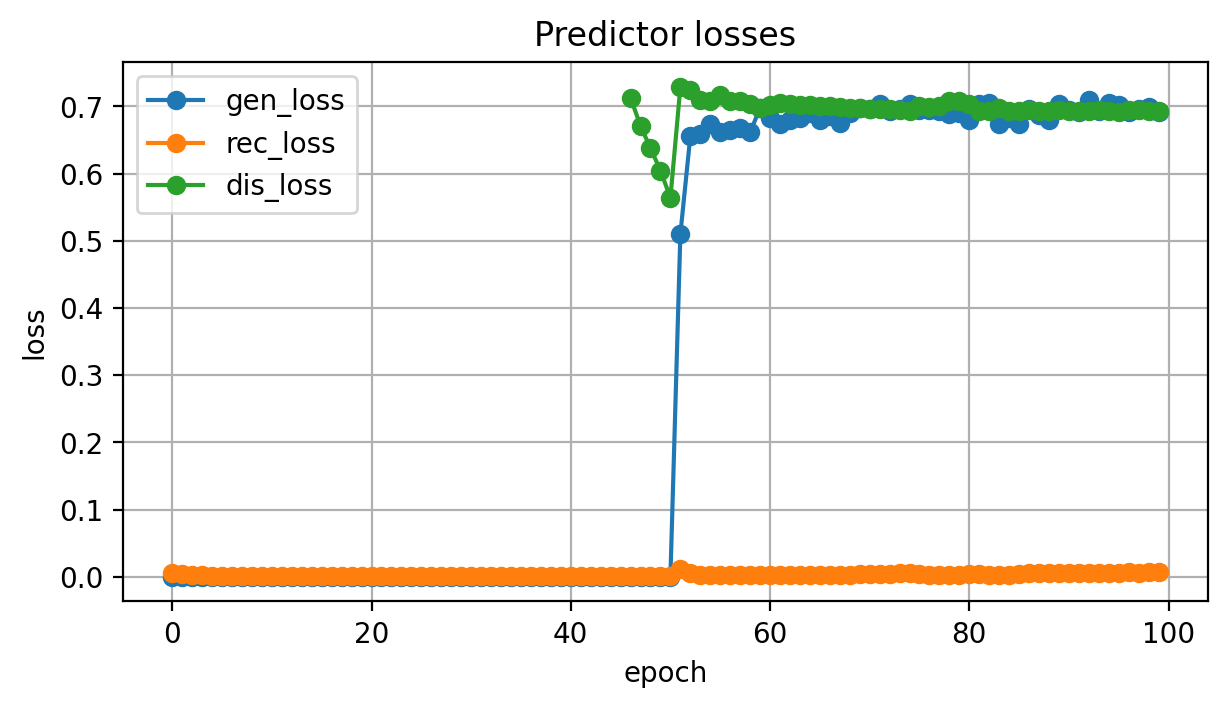

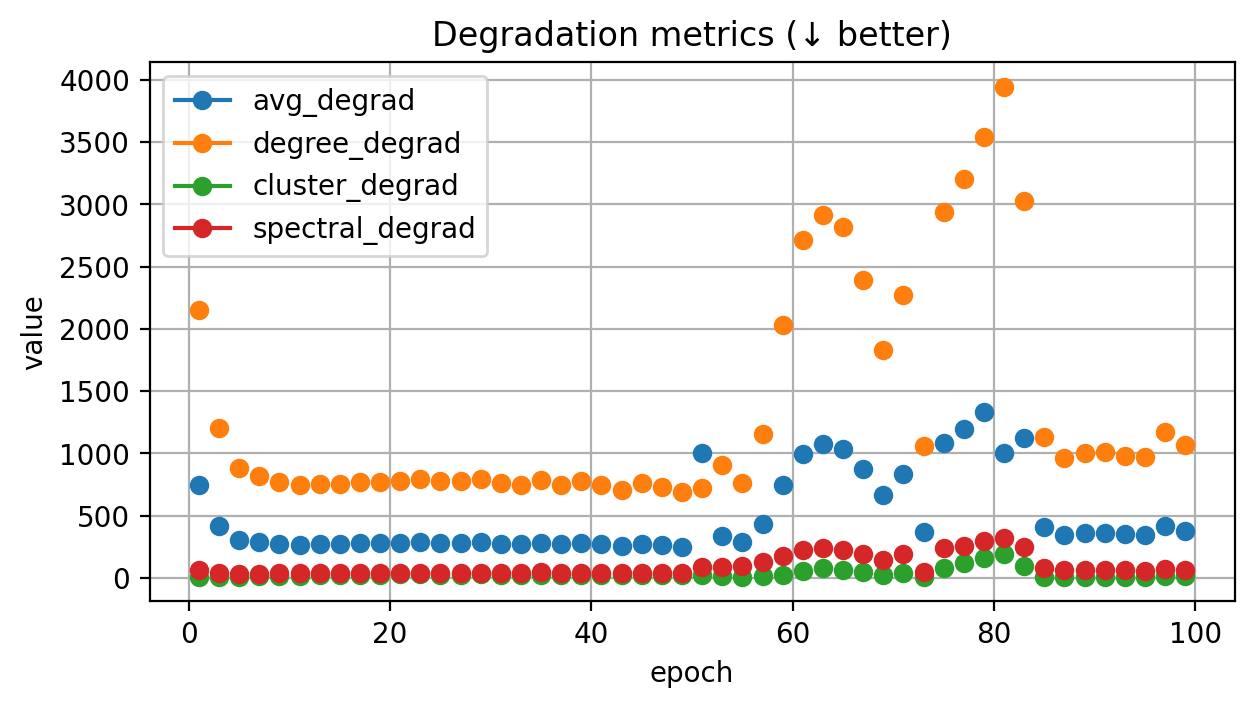

,gen_loss,rec_loss,discriminating,step,degree,cluster,unique,novel,spectral,degree_degrad,cluster_degrad,spectral_degrad,avg_degrad,dis_loss
epoch,,,,,,,,,,,,,,
95,0.701917,0.005900,1.0,12287.0,0.174234,0.043810,0.946939,0.946939,0.067434,968.576843,8.303775,51.031036,342.637207,0.691414
96,0.691275,0.006631,1.0,12415.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.693869
97,0.695506,0.006589,1.0,12543.0,0.211374,0.062738,0.938272,0.938272,0.090315,1175.039673,11.891453,68.346024,418.425751,0.693818
98,0.698491,0.007025,1.0,12671.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.693146
99,0.691695,0.006615,1.0,12799.0,0.191681,0.054847,0.938776,0.938776,0.081554,1065.566040,10.395812,61.716267,379.226044,0.692506


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

log_path = Path(csv_logger.log_dir) / "metrics.csv"   # points to THIS run's CSV
print("metrics CSV:", log_path)

df = pd.read_csv(log_path)
# Aggregate by epoch (Lightning can write multiple rows per epoch)
agg = df.groupby("epoch").mean(numeric_only=True)

to_plot_1 = [c for c in ["gen_loss","rec_loss","dis_loss"] if c in agg.columns]
to_plot_2 = [c for c in ["avg_degrad","degree_degrad","cluster_degrad","spectral_degrad"] if c in agg.columns]

if to_plot_1:
    ax = agg[to_plot_1].plot(marker="o", figsize=(7,3.5), grid=True)
    ax.set_title("Predictor losses"); ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    plt.show()

if to_plot_2:
    ax = agg[to_plot_2].plot(marker="o", figsize=(7,3.5), grid=True)
    ax.set_title("Degradation metrics (↓ better)"); ax.set_xlabel("epoch"); ax.set_ylabel("value")
    plt.show()

# quick peek at the last few rows
agg.tail(5)


## Check Results

In [24]:
# --- imports used in this section ---
import os, glob, numpy as np, torch, networkx as nx, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from utils.eval_helper import (
    degree_stats, clustering_stats, spectral_stats,
    eval_fraction_unique_non_isomorphic_valid,
)
from models.diffusion import SpectralDiffusion

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pred = pred.to(device).eval()

def nx_graphs_from_split(ds, limit=2048):
    """
    Convert a LaplacianDatasetNX split into a list of networkx graphs.
    We undo the Laplacian to get adjacency: A = -L (zeros on diagonal).
    """
    out = []
    for jj in range(min(limit, len(ds))):
        L = ds[jj][-3][:ds[jj][-2], :ds[jj][-2]].cpu().numpy()  # (n,n) Laplacian
        A = -L.copy()
        np.fill_diagonal(A, 0.0)
        out.append(nx.from_numpy_array(A))
    return out

def predict_graphs_from_pairs(model, pair_ds, batch_size=64, thr=0.5):
    """
    Use the *predictor's generator* on diffusion eigenpairs (X=Evec, Y=Eval)
    to produce adjacencies, then convert to networkx graphs.

    Shapes inside:
      - x: (B, N_max, k + feature_size)  [Eigenvectors (+ optional node feats)]
      - y: (B, 1,      k + feature_size) [Eigenvalues (+ optional feats)]
    We:
      1) build the node mask from Evec magnitude (nonzero rows are real nodes)
      2) call model.generator(z, Eval, Evec, mask)  →  (B, N_max, N_max)
      3) binarize with thr and crop to active nodes.
    """
    loader = DataLoader(pair_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    adj_list, nx_graphs = [], []
    model = model.to(device).eval()
    with torch.no_grad():
        for x, y in loader:
            # split spectra (ignore extra features for PROTEINS; feature_size=0 here)
            Evec = x[:, :, :model.hparams.k].to(device)          # (B,N,k)
            Eval = y[:, 0, :model.hparams.k].to(device)          # (B,k)
            node_feats = x[:, :, model.hparams.k:].to(device)    # (B,N,f)   (f=0 on PROTEINS)
            # active nodes = rows whose eigenvector energy is non-zero
            mask = (Evec.abs().sum(-1) > 1e-5)                   # (B,N)

            # latent z: zeros for noise part, concat any node feats that exist
            z = torch.zeros(list(mask.shape[:2]) + [model.generator.latent_dim - model.hparams.feature_size], device=device)
            z = torch.cat([z, node_feats], -1)                   # (B,N,latent_dim)

            # generate full N_max×N_max adjacency, then binarize
            f_adj, _, _ = model.generator(z, Eval, Evec, mask)   # (B,N_max,N_max)
            f_adj = (f_adj.detach().cpu() > thr).float()         # (B,N_max,N_max)

            # crop each graph to its active nodes and build NX objects
            for A in f_adj:
                m = A.sum(-1) > 0
                A = A[m][:, m]
                adj_list.append(A)
                nx_graphs.append(nx.from_numpy_array(A.numpy()))
    return torch.stack(adj_list), nx_graphs



Baseline (train vs val):
  degree   = 0.000285448
  cluster  = 0.00670127
  spectral = 0.00300527

Generated vs val:
  degree   = 0.182256
  cluster  = 0.050883
  spectral = 0.0785494

Degradation ratios (↓ better; ~1 == train↔val):
  degree_degrad   = 638
  cluster_degrad  = 7.59
  spectral_degrad = 26.1
  avg_degrad      = 224

Uniqueness = 0.939   Novelty = 0.939


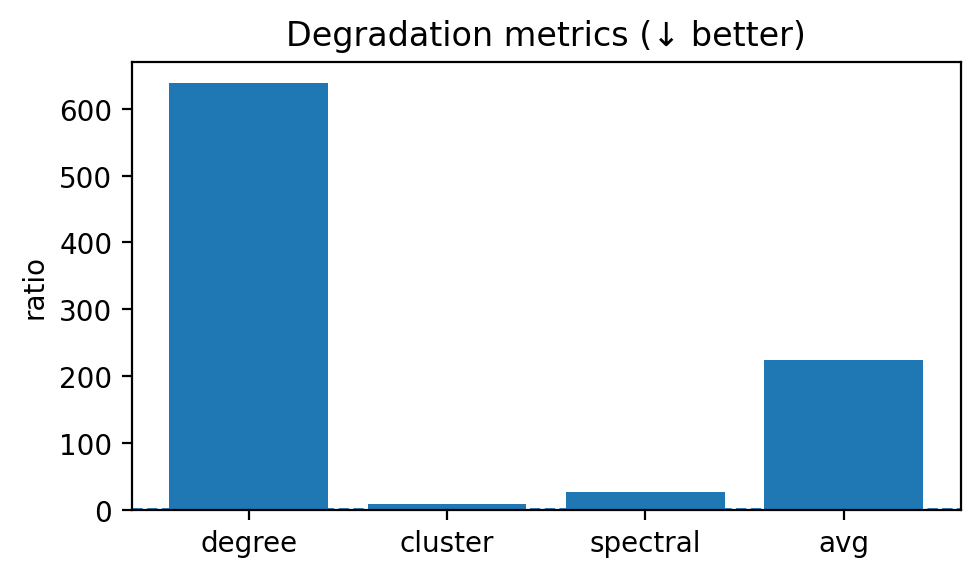

In [26]:
# Baseline denominators (train ↔ val)
baseline_degree   = float(degree_stats(  real_val_nx, real_train_nx, compute_emd=False))
baseline_cluster  = float(clustering_stats(real_val_nx, real_train_nx, compute_emd=False))
baseline_spectral = float(spectral_stats( real_val_nx, real_train_nx, compute_emd=False))

# Numerators (generated ↔ val)
num_degree   = float(degree_stats(  real_val_nx, gen_clean, compute_emd=False))
num_cluster  = float(clustering_stats(real_val_nx, gen_clean, compute_emd=False))
num_spectral = float(spectral_stats( real_val_nx, gen_clean, compute_emd=False))

# Ratios (↓ better; ~1 means as good as train↔val)
eps = 1e-12
deg_ratio = num_degree   / max(baseline_degree,   eps)
clu_ratio = num_cluster  / max(baseline_cluster,  eps)
spe_ratio = num_spectral / max(baseline_spectral, eps)
avg_ratio = (deg_ratio + clu_ratio + spe_ratio) / 3.0

print("\nBaseline (train vs val):")
print(f"  degree   = {baseline_degree:.6g}")
print(f"  cluster  = {baseline_cluster:.6g}")
print(f"  spectral = {baseline_spectral:.6g}")

print("\nGenerated vs val:")
print(f"  degree   = {num_degree:.6g}")
print(f"  cluster  = {num_cluster:.6g}")
print(f"  spectral = {num_spectral:.6g}")

print("\nDegradation ratios (↓ better; ~1 == train↔val):")
print(f"  degree_degrad   = {deg_ratio:.3g}")
print(f"  cluster_degrad  = {clu_ratio:.3g}")
print(f"  spectral_degrad = {spe_ratio:.3g}")
print(f"  avg_degrad      = {avg_ratio:.3g}")

# Additional: uniqueness & novelty vs train set
uniq, nov, _ = eval_fraction_unique_non_isomorphic_valid(gen_clean, real_train_nx)
print(f"\nUniqueness = {uniq:.3f}   Novelty = {nov:.3f}")

# Quick bar plot
plt.figure(figsize=(5,3))
plt.bar(["degree","cluster","spectral","avg"], [deg_ratio,clu_ratio,spe_ratio,avg_ratio])
plt.axhline(1.0, ls="--", lw=1)  # train↔val baseline
plt.ylabel("ratio"); plt.title("Degradation metrics (↓ better)")
plt.tight_layout(); plt.show()


Using diffusion ckpt: /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints/diffusion_proteins_k16-final.ckpt


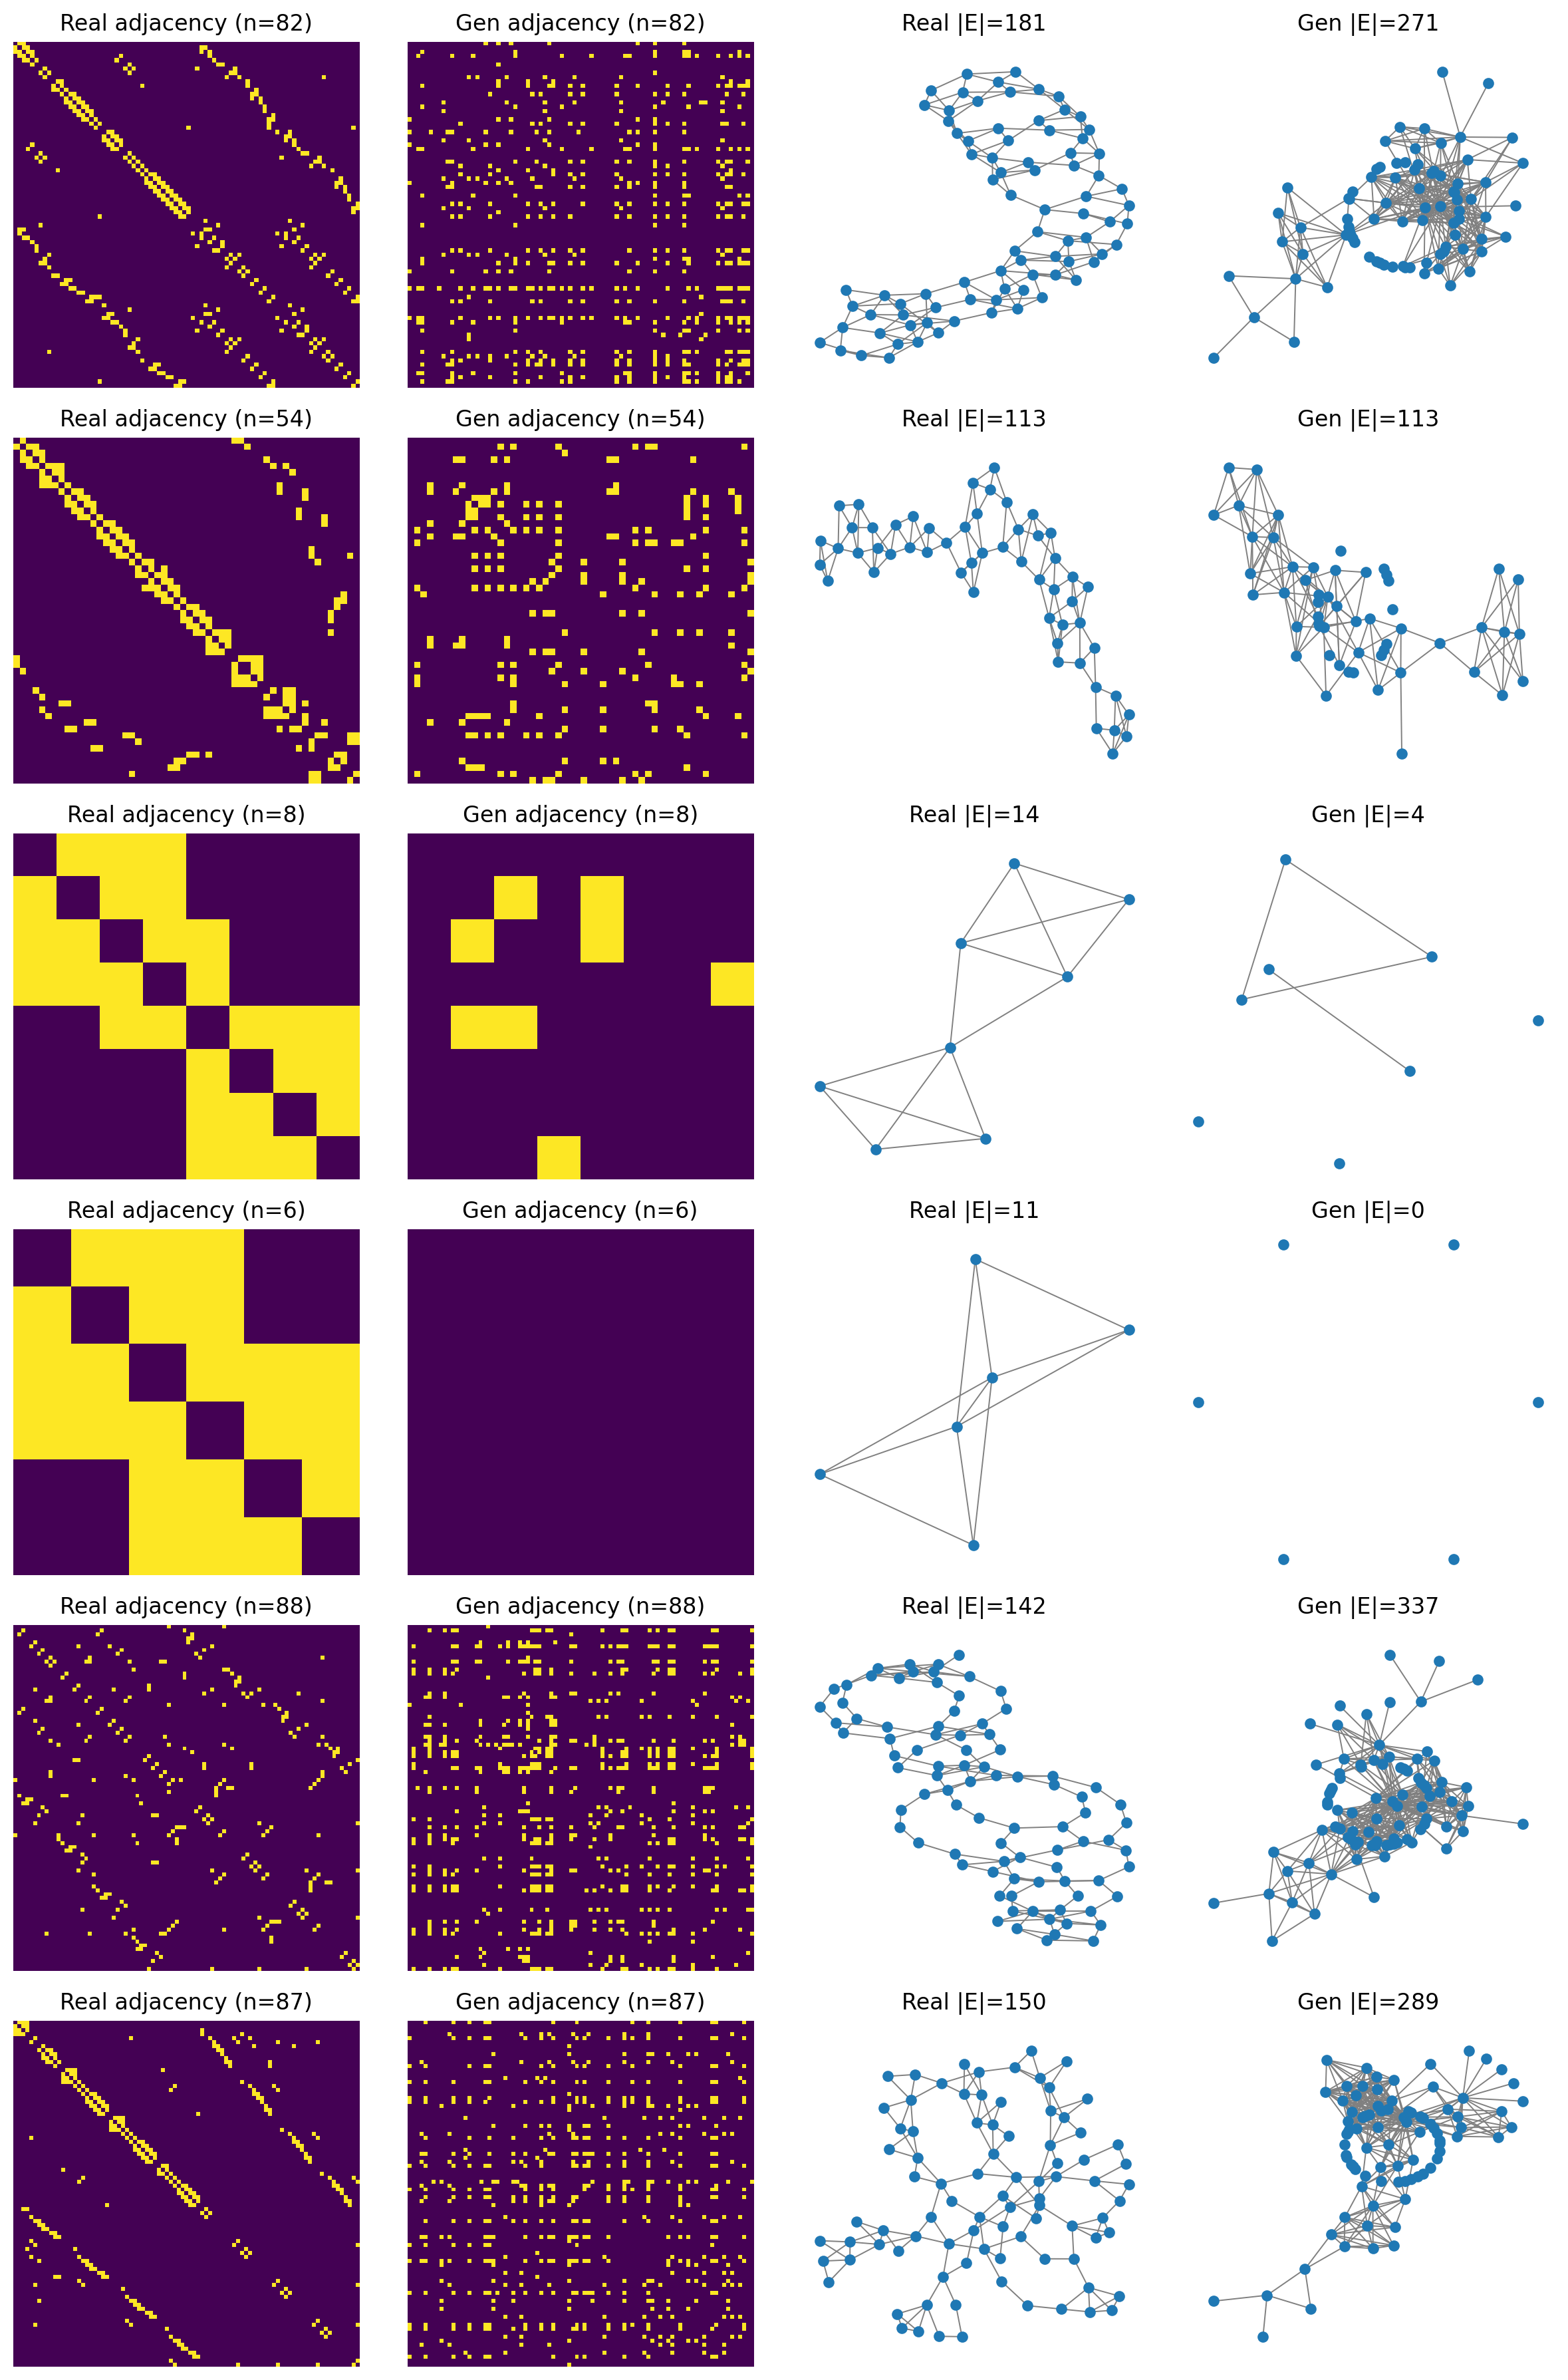

In [32]:
# --- 5.1 Resolve diffusion checkpoint robustly ---
def resolve_diffusion_ckpt(dataset="proteins", k=16, ckpt_dir=None):
    import os, glob
    roots = []
    if ckpt_dir is not None:
        roots.append(str(ckpt_dir))
    roots += [
        "/nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints",
        str(CKPT) if 'CKPT' in globals() else ".",
        ".",
    ]
    pats = [f"diffusion_{dataset}_k{k}-*.ckpt", "*.ckpt"]
    for r in roots:
        if not os.path.isdir(r):
            continue
        for pat in pats:
            hits = sorted(glob.glob(os.path.join(r, pat)),
                          key=os.path.getmtime, reverse=True)
            for h in hits:
                if "diffusion" in os.path.basename(h):
                    return h
    raise FileNotFoundError("Diffusion ckpt not found – pass a valid path.")

diff_ckpt = resolve_diffusion_ckpt(dataset="proteins", k=pred.hparams.k)
print("Using diffusion ckpt:", diff_ckpt)


# --- 5.2 Sample eigenpairs for chosen sizes, then run predictor ---
def sample_pairs_for_sizes(ckpt_path, sizes, k=16, device="cuda", steps=200):
    """
    Ask the diffusion model to generate (Evec, Eval) for specific node counts.
    We reuse train split scalers from graphs_train.
    """
    model = SpectralDiffusion.load_from_checkpoint(
        ckpt_path, strict=False, map_location=device
    ).eval().to(device)

    scale_xy = graphs_train.scale_xy
    unscale_xy = graphs_train.unscale_xy
    with torch.no_grad():
        XX, YY = model.sample_eigs(
            max_nodes=list(int(s) for s in sizes),
            num_eigs=k + getattr(model.hparams, "feature_size", 0),
            scale_xy=scale_xy, unscale_xy=unscale_xy,
            device=device, num_graphs=len(sizes),
            reproject=True, sampling_steps=steps,
        )
    del model
    torch.cuda.empty_cache()
    return XX.cpu(), YY.cpu()


def predictor_from_pairs(model, X, Y, thr=0.5, device="cuda", enforce_n=None):
    """
    Run the predictor's generator and crop by the *mask* (or exact sizes if provided).
    This avoids dropping isolated nodes and makes Gen n == requested n.
    """
    model = model.to(device).eval()
    with torch.no_grad():
        Evec = X[:, :, :model.hparams.k].to(device)          # (B, N_max, k)
        Eval = Y[:, 0, :model.hparams.k].to(device)          # (B, k)
        node = X[:, :, model.hparams.k:].to(device)          # (B, N_max, f)

        # Infer mask from eigenvector energy, then optionally override to exact n
        mask = (Evec.abs().sum(-1) > 1e-8)                   # (B, N_max) bool
        if enforce_n is not None:
            B, Nmax = mask.shape
            new_mask = torch.zeros_like(mask)
            for b in range(B):
                n = int(enforce_n[b])
                new_mask[b, :n] = True
            mask = new_mask

        # Build latent (noise part + optional node feats)
        z = torch.zeros(list(mask.shape[:2]) + 
                        [model.generator.latent_dim - model.hparams.feature_size],
                        device=device)
        z = torch.cat([z, node], -1)                         # (B, N_max, latent_dim)

        # Generate dense adj, then threshold
        f_adj, _, _ = model.generator(z, Eval, Evec, mask)   # (B, N_max, N_max)
        f_adj = (f_adj.detach().cpu() > thr).float()

    # Crop each graph strictly by the mask (or exact size)
    cropped = []
    mask_cpu = mask.cpu()
    for b in range(f_adj.shape[0]):
        m = mask_cpu[b]
        A = f_adj[b][m][:, m]
        cropped.append(A)
    return cropped  # list[Tensor (n_i, n_i)]


# --- 5.3 Pick k validation graphs and compare side-by-side ---
kshow = 6
val_idx = np.random.choice(len(graphs_val), kshow, replace=False)
sizes   = [int(graphs_val[i][-2]) for i in val_idx]   # the exact n for each chosen real graph

XX, YY  = sample_pairs_for_sizes(diff_ckpt, sizes, k=pred.hparams.k, device=device, steps=200)
gen_cropped = predictor_from_pairs(pred, XX, YY, thr=0.5, device=device, enforce_n=sizes)

def real_adj_from_idx(ds, i):
    L = ds[i][-3][:ds[i][-2], :ds[i][-2]].cpu().numpy()
    A = -L.copy()
    np.fill_diagonal(A, 0.0)
    return torch.tensor(A, dtype=torch.float32)

# plot: [real adj][gen adj][real draw][gen draw]
fig, axes = plt.subplots(kshow, 4, figsize=(12, 3*kshow))
for r, i in enumerate(val_idx):
    A_real = real_adj_from_idx(graphs_val, i)
    A_gen  = gen_cropped[r]

    axes[r,0].imshow(A_real, interpolation="nearest")
    axes[r,0].set_title(f"Real adjacency (n={A_real.shape[0]})")
    axes[r,0].axis("off")

    axes[r,1].imshow(A_gen, interpolation="nearest")
    axes[r,1].set_title(f"Gen adjacency (n={A_gen.shape[0]})")  # == sizes[r]
    axes[r,1].axis("off")

    Greal = nx.from_numpy_array(A_real.numpy())
    Ggen  = nx.from_numpy_array(A_gen.numpy())
    pos_r = nx.kamada_kawai_layout(Greal)
    pos_g = nx.kamada_kawai_layout(Ggen)

    nx.draw(Greal, pos_r, ax=axes[r,2], node_size=25, edge_color="gray", width=0.7)
    axes[r,2].set_title(f"Real |E|={Greal.number_of_edges()}"); axes[r,2].axis("off")
    nx.draw(Ggen,  pos_g, ax=axes[r,3], node_size=25, edge_color="gray", width=0.7)
    axes[r,3].set_title(f"Gen |E|={Ggen.number_of_edges()}");   axes[r,3].axis("off")

plt.tight_layout(); plt.show()


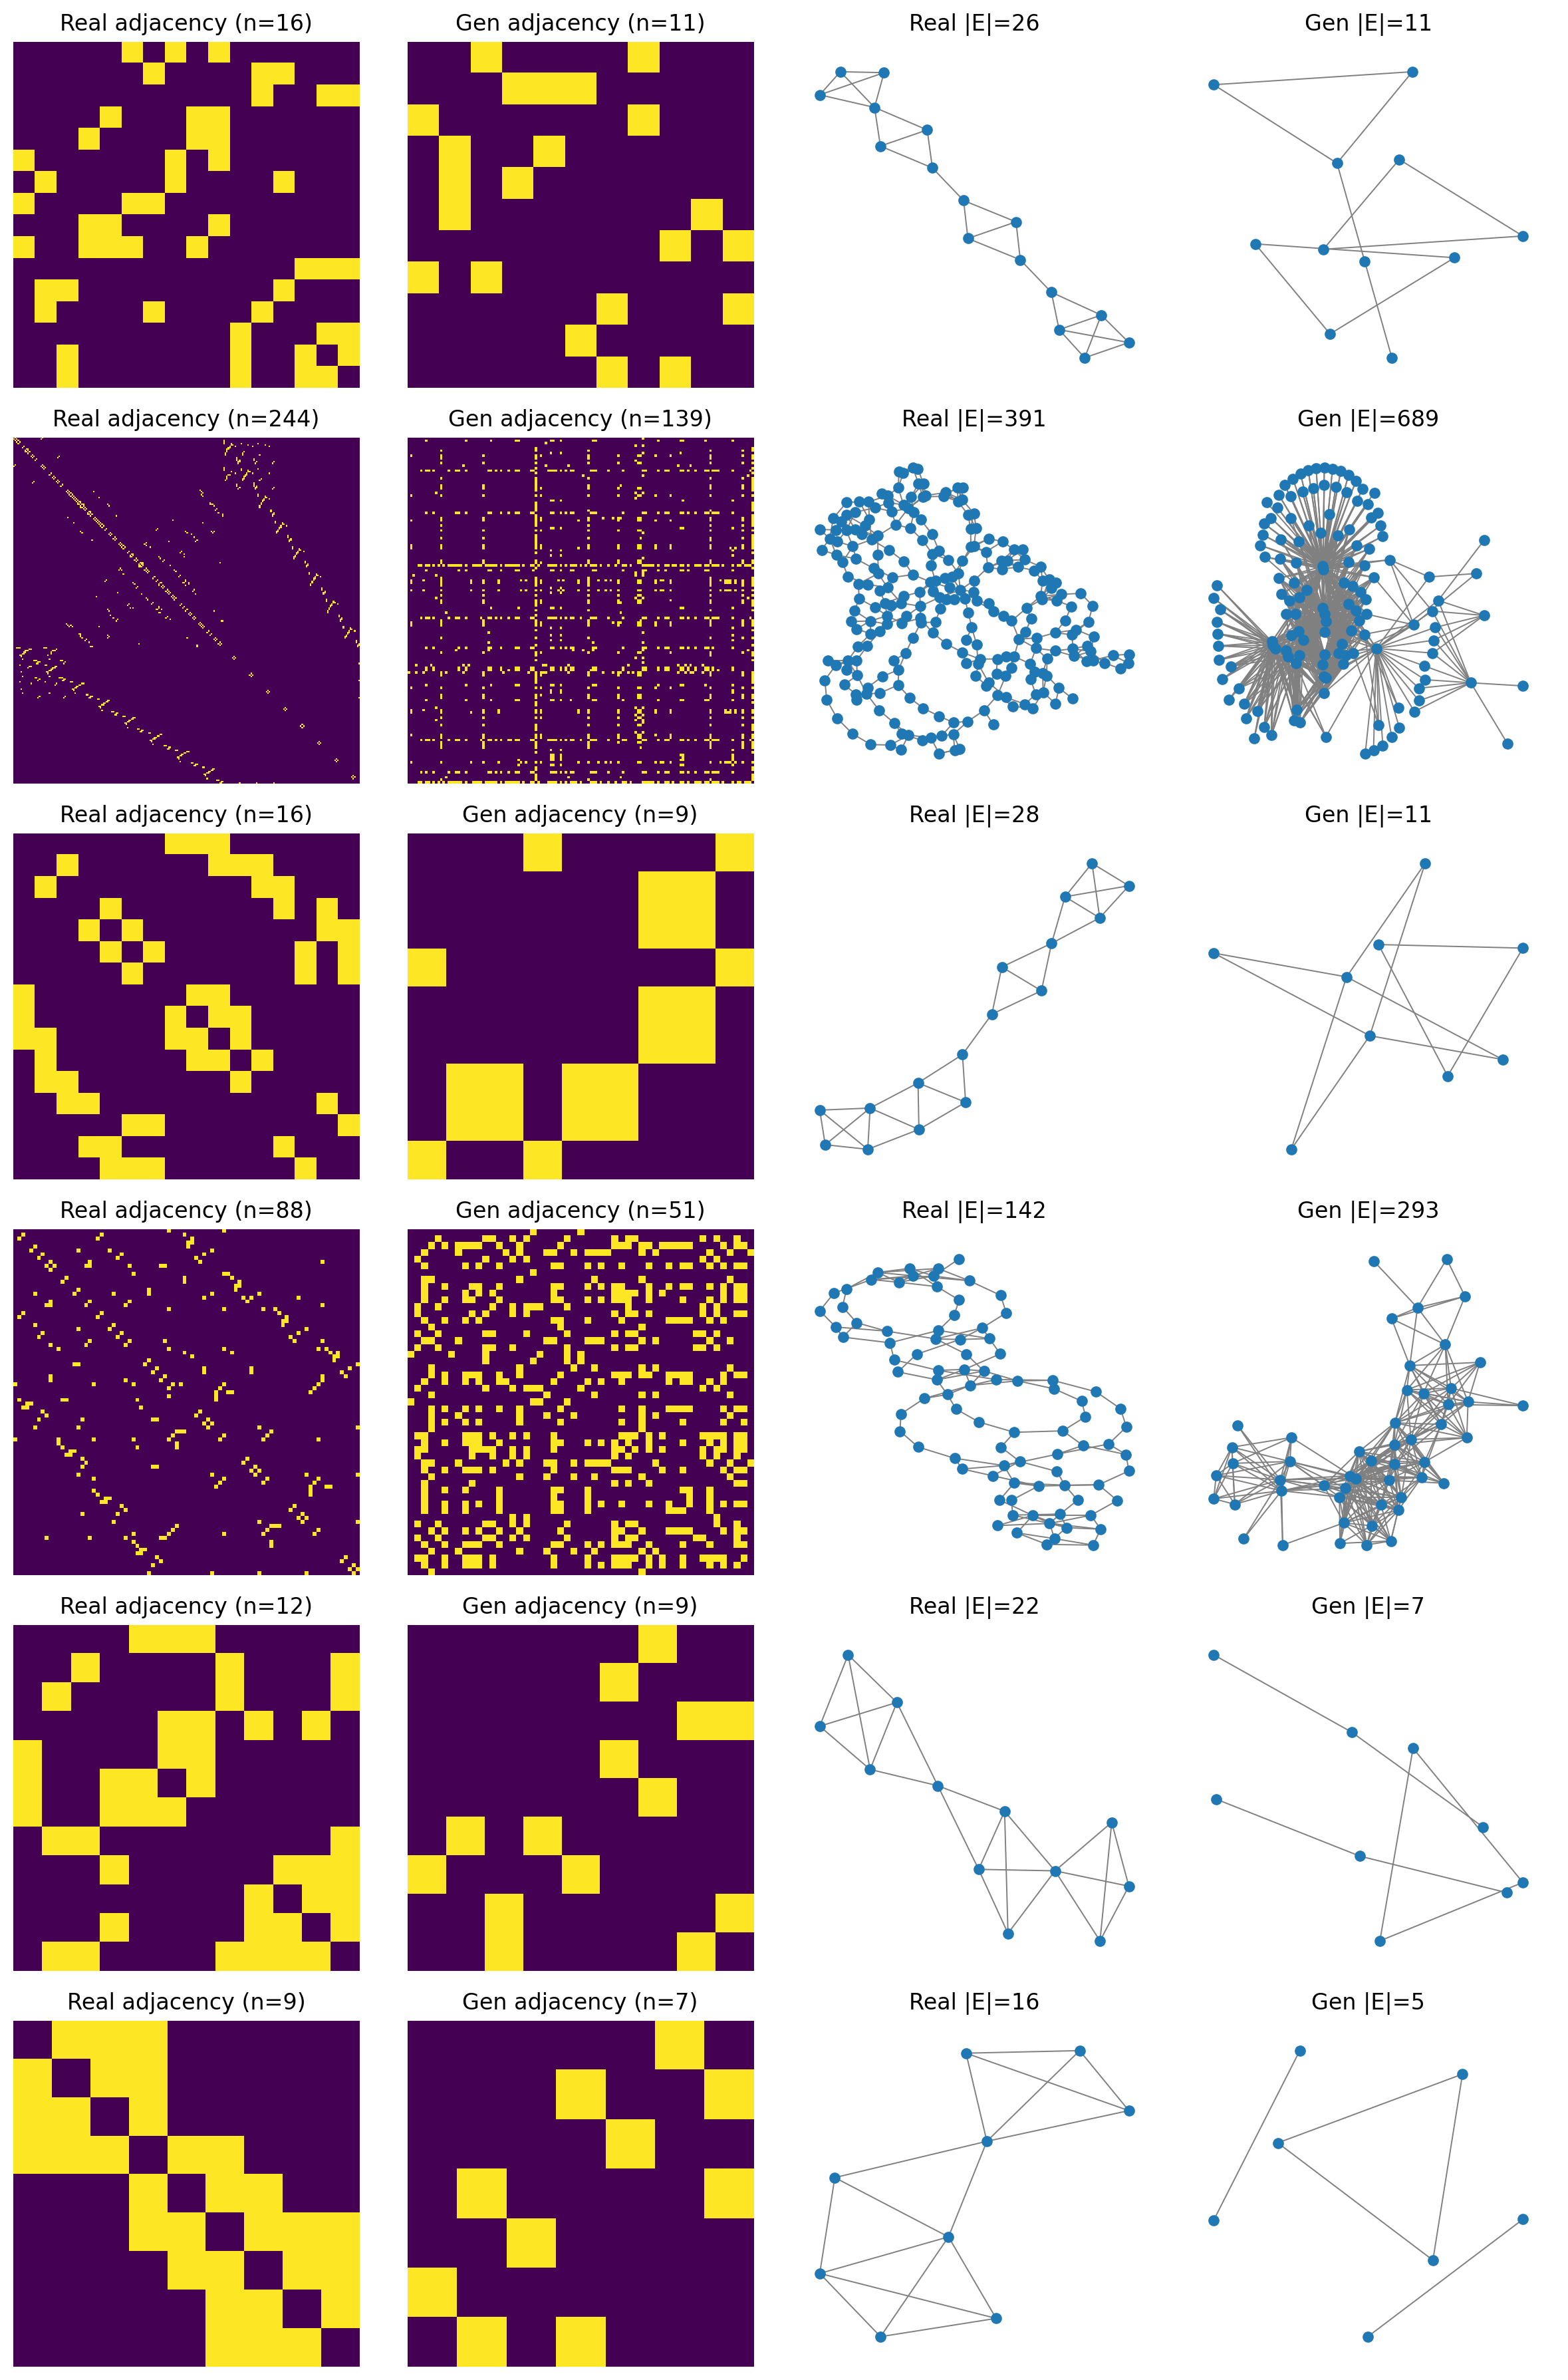

In [31]:
# --- 5.3 Pick k validation graphs and compare side-by-side ---
kshow = 6
val_idx = np.random.choice(len(graphs_val), kshow, replace=False)
sizes   = [int(graphs_val[i][-2]) for i in val_idx]   # number of nodes in each chosen real graph

XX, YY  = sample_pairs_for_sizes(diff_ckpt, sizes, k=pred.hparams.k, device=device, steps=200)
gen_cropped = predictor_from_pairs(pred, XX, YY, thr=0.5, device=device)

def real_adj_from_idx(ds, i):
    L = ds[i][-3][:ds[i][-2], :ds[i][-2]].cpu().numpy()
    A = -L.copy(); np.fill_diagonal(A, 0.0)
    return torch.tensor(A, dtype=torch.float32)

# plot: [real adj][gen adj][real draw][gen draw]
fig, axes = plt.subplots(kshow, 4, figsize=(12, 3*kshow))
for r, i in enumerate(val_idx):
    A_real = real_adj_from_idx(graphs_val, i)
    A_gen  = gen_cropped[r]

    axes[r,0].imshow(A_real, interpolation="nearest"); axes[r,0].set_title(f"Real adjacency (n={A_real.shape[0]})"); axes[r,0].axis("off")
    axes[r,1].imshow(A_gen , interpolation="nearest"); axes[r,1].set_title(f"Gen adjacency (n={A_gen.shape[0]})");  axes[r,1].axis("off")

    Greal = nx.from_numpy_array(A_real.numpy())
    Ggen  = nx.from_numpy_array(A_gen.numpy())
    pos_r = nx.kamada_kawai_layout(Greal)
    pos_g = nx.kamada_kawai_layout(Ggen)

    nx.draw(Greal, pos_r, ax=axes[r,2], node_size=25, edge_color="gray", width=0.7)
    axes[r,2].set_title(f"Real |E|={Greal.number_of_edges()}"); axes[r,2].axis("off")
    nx.draw(Ggen , pos_g, ax=axes[r,3], node_size=25, edge_color="gray", width=0.7)
    axes[r,3].set_title(f"Gen |E|={Ggen.number_of_edges()}");   axes[r,3].axis("off")

plt.tight_layout(); plt.show()
